# Lab 1.3: SuperBPE - Space Travel for Language Models

**Course:** Advanced Natural Language Processing (NLP702/806)

**Instructor:** Dr. Fajri Koto

---

**SuperBPE** ([Liu et al., 2025](https://superbpe.github.io)) is a recent breakthrough in tokenization that extends traditional BPE by learning **multi-word tokens** (called "superwords") in addition to subword tokens.

Traditional BPE has a critical constraint: **whitespace pretokenization**. Before BPE training begins, text is split on whitespace:

```
Text: "New York City is amazing"
After whitespace split: ["New", "York", "City", "is", "amazing"]
BPE can only learn patterns WITHIN each word
```

This means traditional BPE can learn:
- Subwords like "ing", "tion", "pre-"
- Complete words like "New", "York"

**The Problem:** Many meaningful linguistic units span multiple words!
- Named entities: "New York", "San Francisco", "United States"
- Common phrases: "as well as", "in order to", "machine learning"
- Technical terms: "neural network", "natural language processing"

### SuperBPE's Innovation: "Space Travel" 🌌

SuperBPE removes the whitespace barrier, allowing merges to happen **across word boundaries**. This is why it's called "Space Travel" - tokens can now traverse spaces!

**How it works:**

1. **No pretokenization**: Start with raw character sequence (including spaces)
   ```
   "New York City" → ['N', 'e', 'w', ' ', 'Y', 'o', 'r', 'k', ' ', 'C', 'i', 't', 'y']
   ```

2. **Learn merges across ALL boundaries**:
   ```
   Merge 1: 'N' + 'e' → 'Ne'
   Merge 2: 'w' + ' ' → 'w '
   Merge 3: 'w ' + 'Y' → 'w Y'    ← This crosses a word boundary!
   ...
   Eventually: 'New York' as a single token
   ```

3. **Result**: Vocabulary contains both subwords AND superwords
   - Subwords: "ing", "pre", "tion"
   - Words: "learning", "data"
   - Superwords: "New York", "machine learning", "as well as"

### Connection to Your Understanding

Think back to our PPAP example:
- Traditional BPE learned: `"pineapple"` → `['pine', 'apple</w>']`
- SuperBPE could learn: `"apple pen"` → `['apple pen']` (if frequent enough!)

This is the key difference: SuperBPE treats the entire text as a continuous sequence, while traditional BPE treats each word independently.

In [11]:
!rm -rf data/superbpe

In [12]:
# Import superbpe module
import sys
import os

# Clone SuperBPE repository if not already cloned
if not os.path.exists('data/superbpe'):
    !git clone https://github.com/PythonNut/superbpe data/superbpe
else:
    print("✓ SuperBPE repository already cloned")

sys.path.insert(0, './data/superbpe')

Cloning into 'data/superbpe'...
remote: Enumerating objects: 503, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 503 (delta 14), reused 12 (delta 11), pack-reused 479 (from 1)
Receiving objects: 100% (503/503), 47.49 MiB | 12.09 MiB/s, done.
Resolving deltas: 100% (395/395), done.


In [13]:
# Let's start with necessary imports
import os
import re
import time
import random
import simdjson as json

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# NLP libraries
from datasets import load_dataset

# Tokenization libraries
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Transformers logging
from transformers import logging
logging.enable_progress_bar()  
logging.set_verbosity_info()

from data.superbpe.utils import get_files_with_num_bytes, get_truncated_file, train_or_extend_tokenizer

In [14]:
print(f"Loading datasets...")

raw_texts: list[str] = []

# 1) Python code from datasets
print("  - Loading Python code samples...")
try:
    code_dataset = load_dataset("codeparrot/github-code",
                                streaming=True,
                                languages=["Python"],
                                split="train",
                                trust_remote_code=True)
    code_texts = []
    for i, item in enumerate(code_dataset):
        if i >= 5000:  # Take 1000 code samples
            break
        if 'code' in item:
            code_texts.append(item['code'])
    raw_texts.extend(code_texts)
    print(f"    ✓ Loaded {len(code_texts)} code samples")
except Exception as e:
    print(f"    ⚠️  Could not load code dataset: {e}")
    # Fallback: synthetic code examples (EXPANDED)
    code_examples = [
        'def train_model(X, y):\n    """Train ML model"""\n    model = RandomForest(n_estimators=100)\n    model.fit(X, y)\n    return model',
        'class TokenizerBPE:\n    def __init__(self, vocab_size=50000):\n        self.vocab = {}\n    def encode(self, text: str) -> List[int]:\n        return [self.vocab.get(t, 0) for t in text.split()]',
        'import numpy as np\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\n\nX_train, X_test = train_test_split(data, test_size=0.2)',
        '# API endpoint\n@app.route("/api/v1/tokenize", methods=["POST"])\ndef tokenize():\n    data = request.get_json()\n    return {"tokens": tokenizer.encode(data["text"])}',
        'async function fetchData(url) {\n  try {\n    const response = await fetch(url);\n    return await response.json();\n  } catch (error) {\n    console.error("Error:", error);\n  }\n}',
        'SELECT users.name, COUNT(orders.id) AS order_count\nFROM users\nLEFT JOIN orders ON users.id = orders.user_id\nGROUP BY users.id\nHAVING order_count > 5;',
        'package main\n\nimport "fmt"\n\nfunc main() {\n    fmt.Println("Hello, World!")\n    numbers := []int{1, 2, 3, 4, 5}\n    for _, num := range numbers {\n        fmt.Printf("%d ", num)\n    }\n}',
        'public class Calculator {\n    public static int add(int a, int b) {\n        return a + b;\n    }\n    public static void main(String[] args) {\n        System.out.println(add(5, 3));\n    }\n}',
    ]
    raw_texts.extend(code_examples * 500)

# 2) Wikipedia text (encyclopedic, diverse topics)
print("  - Loading Wikipedia samples...")
try:
    wiki_dataset = load_dataset("wikipedia", "20220301.en",
                                split="train",
                                streaming=True,
                                trust_remote_code=True)
    wiki_texts = []
    for i, item in enumerate(wiki_dataset):
        if i >= 2000:  # Take 1000 Wikipedia articles
            break
        if 'text' in item and len(item['text']) > 200:
            # Take first few paragraphs
            wiki_texts.append(item['text'][:1000])
    raw_texts.extend(wiki_texts)
    print(f"    ✓ Loaded {len(wiki_texts)} Wikipedia samples")
except Exception as e:
    print(f"    ⚠️  Could not load Wikipedia: {e}")
    # Fallback: technical Wikipedia-style text (EXPANDED)
    wiki_examples = [
        "Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions.",
        "Natural language processing (NLP) is an interdisciplinary subfield of computer science and artificial intelligence. It is primarily concerned with providing computers the ability to process data encoded in natural language.",
        "The Transformer architecture introduced the attention mechanism, allowing models to weigh the importance of different parts of the input data. This revolutionized sequence-to-sequence tasks in NLP.",
        "Byte pair encoding (BPE) is a data compression technique that iteratively replaces the most frequent pair of bytes in a sequence with a single, unused byte. It's widely used in natural language processing for subword tokenization.",
        "Python is a high-level, interpreted programming language with dynamic semantics. Its high-level built-in data structures, combined with dynamic typing and binding, make it very attractive for Rapid Application Development.",
        "The Internet Protocol (IP) is the network layer communications protocol in the Internet protocol suite for relaying datagrams across network boundaries. Its routing function enables internetworking.",
        "Convolutional Neural Networks (CNNs) are a class of deep learning algorithms that can take in an input image, assign importance to various aspects/objects in the image and be able to differentiate one from the other.",
        "REST (REpresentational State Transfer) is an architectural style for providing standards between computer systems on the web, making it easier for systems to communicate with each other.",
    ]
    raw_texts.extend(wiki_examples * 500)

# 3) Technical documentation and web text
print("  - Loading web text samples...")
try:
    web_dataset = load_dataset("allenai/c4",
                                "en",
                                split="train",
                                streaming=True,
                                trust_remote_code=True)
    web_texts = []
    for i, item in enumerate(web_dataset):
        if i >= 2000:  # Take 1000 web samples
            break
        if 'text' in item and len(item['text']) > 100:
            web_texts.append(item['text'][:800])
    raw_texts.extend(web_texts)
    print(f"    ✓ Loaded {len(web_texts)} web text samples")
except Exception as e:
    print(f"    ⚠️  Could not load web dataset: {e}")
    # Fallback: synthetic web text examples (EXPANDED)
    web_examples = [
        "The API returns JSON: {\"status\": 200, \"data\": [1,2,3], \"message\": \"Success\"}",
        "Install via: pip install transformers torch numpy pandas scikit-learn matplotlib",
        "Email: support@example.com | Phone: +1-555-0123 | URL: https://www.example.com/docs",
        "Error: ModuleNotFoundError: No module named 'tokenizers'. Run: pip install tokenizers",
        "TODO: Fix bug in tokenization pipeline. See issue #42 @username",
        "Math equation: f(x) = ∑(i=1 to n) w_i * x_i + b, where w ∈ ℝ^n",
        "Currency: $1,234.56 USD | €987.65 EUR | ¥10,000 JPY | £543.21 GBP",
        "Code review feedback: LGTM! ✓ Tests pass ✓ Coverage: 95.2% ↑",
        "Debug output: TypeError: unsupported operand type(s) for +: 'int' and 'str' at line 42",
        "Database query: SELECT * FROM users WHERE age > 21 AND country IN ('US', 'UK', 'CA');",
        "Regex pattern: r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}$'",
        "HTML snippet: <div class=\"container\"><h1>Hello World!</h1><p>Welcome to my site.</p></div>",
        "Configuration: {'batch_size': 32, 'learning_rate': 0.001, 'epochs': 100, 'optimizer': 'Adam'}",
        "Git command: git commit -m 'feat: Add new tokenizer implementation' && git push origin main",
        "Performance: Throughput: 1,234 req/s | Latency: p50=12ms, p95=45ms, p99=120ms",
        "Unicode test: Hello 世界! Привет мир! مرحبا العالم! 🚀 🎉 ⚡",
    ]
    raw_texts.extend(web_examples * 500)

# ---------- Cleaning ----------
def clean_text(text: str) -> str:
    # Normalize whitespace but PRESERVE case and Unicode
    text = re.sub(r"\s+", " ", text)
    # Remove only control characters (but keep newlines as spaces)
    text = re.sub(r"[\x00-\x08\x0B-\x0C\x0E-\x1F\x7F]", "", text)
    text = text.strip()

    return text

cleaned = []
for t in raw_texts:
    ct = clean_text(t)
    if len(ct) > 20:  # Slightly higher threshold
        cleaned.append(ct)

# ---------- Prevent exact-duplicate leakage ----------
cleaned_unique = list(dict.fromkeys(cleaned))

# ---------- Train/test split ----------
rng = random.Random(42)
rng.shuffle(cleaned_unique)

split_point = int(0.8 * len(cleaned_unique))
train_texts = cleaned_unique[:split_point]
test_texts = cleaned_unique[split_point:]

print(f"\n✅ Dataset loaded successfully!")
print(f"Total raw texts: {len(raw_texts)}")
print(f"Total cleaned unique texts: {len(cleaned_unique)}")
print(f"Training texts: {len(train_texts)}")
print(f"Test texts: {len(test_texts)}")
print(
    f"Average text length: {np.mean([len(t) for t in cleaned_unique]):.1f} characters")
print(f"Total training characters: {sum(len(t) for t in train_texts):,}")

# Analyze dataset characteristics
all_text = " ".join(train_texts[:1000])  # Sample for analysis
has_uppercase = sum(1 for c in all_text if c.isupper())
has_special = sum(1 for c in all_text if c in '{}[]()@#$%^&*')

print(f"\nDataset characteristics:")
print(
    f"  - Uppercase letters: {has_uppercase:,} ({100*has_uppercase/len(all_text):.1f}%)")
print(
    f"  - Special characters: {has_special:,} ({100*has_special/len(all_text):.1f}%)")
print(f"  - Unique chars in sample: {len(set(all_text))}")

print("\nSample training texts:")
for i, t in enumerate(train_texts[:3], start=1):
    print(f"{i}. {t[:120]}...")

# Save datasets in txt files for future use
os.makedirs("data/corpus", exist_ok=True)
with open("data/corpus/train_texts.txt", "w", encoding="utf-8") as f:
    for line in train_texts:
        f.write(line + "\n")
with open("data/corpus/test_texts.txt", "w", encoding="utf-8") as f:
    for line in test_texts:
        f.write(line + "\n")

Loading datasets...
  - Loading Python code samples...
    ✓ Loaded 5000 code samples
  - Loading Wikipedia samples...
    ✓ Loaded 1994 Wikipedia samples
  - Loading web text samples...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

    ✓ Loaded 1990 web text samples

✅ Dataset loaded successfully!
Total raw texts: 8984
Total cleaned unique texts: 8969
Training texts: 7175
Test texts: 1794
Average text length: 3185.0 characters
Total training characters: 23,410,169

Dataset characteristics:
  - Uppercase letters: 221,096 (5.7%)
  - Special characters: 147,269 (3.8%)
  - Unique chars in sample: 1816

Sample training texts:
1. #!/bin/env node 'use strict'; var winston = require('winston'), path = require('path'), mcapi = require('mailchimp-api')...
2. class Client { constructor(http_client){ this.http_client = http_client this.method_list = [] } xyz() { return this.http...
3. package plugin_test import ( "path/filepath" "code.cloudfoundry.org/cli/utils/testhelpers/pluginbuilder" . "github.com/o...


In [15]:
VOCAB_SIZE = 10_000
NUM_BYTES = None  # Use all available training data

OUTPUT_PARENT_DIR = f"data/tokenizers/"
os.makedirs(OUTPUT_PARENT_DIR, exist_ok=True)

CORPUS_DIR = "data/corpus/"
os.makedirs(CORPUS_DIR, exist_ok=True)

CORPUS_TRAIN_FILE = os.path.join(CORPUS_DIR, "train_texts.txt")
CORPUS_TEST_FILE = os.path.join(CORPUS_DIR, "test_texts.txt")

# Section 1: Train BPE Tokenizer

Let's trained a **standard BPE tokenizer** with whitespace pretokenization. This is the baseline approach used by most modern tokenizers (GPT, BERT, etc.).

**Key Points:**
- **Whitespace pretokenization**: Text is split on spaces BEFORE BPE training
- **Within-word merges only**: Can learn "ing", "tion", but NOT "New_York"

Notice how the tokenizer splits the test sentence into subword units. This is efficient for common words but requires multiple tokens for rare or compound terms.

In [16]:
def train_bpe(vocab_size: int = VOCAB_SIZE, 
              save_path: str = f"{OUTPUT_PARENT_DIR}/bpe_{VOCAB_SIZE}/tokenizer.json") -> Tokenizer:
    """
    Train a standard BPE tokenizer using HuggingFace tokenizers.
    
    Args:
        vocab_size: Target vocabulary size
        save_path: Path to save the trained tokenizer
    
    Returns:
        Trained tokenizer
    """
    print(f"Training standard BPE tokenizer with vocab_size={vocab_size}...")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    # Initialize BPE tokenizer
    tokenizer = Tokenizer(BPE())
    
    # IMPORTANT: Add whitespace pretokenization (standard BPE approach)
    tokenizer.pre_tokenizer = Whitespace()
    
    # Setup trainer
    trainer = BpeTrainer(show_progress=True, vocab_size=vocab_size)
    
    # Train the tokenizer
    start_time = time.time()
    tokenizer.train([CORPUS_TRAIN_FILE], trainer)
    train_time = time.time() - start_time
    
    # Save tokenizer
    tokenizer.save(save_path)
    
    print(f"✅ Training completed in {train_time:.2f} seconds")
    print(f"Vocabulary size: {tokenizer.get_vocab_size()}")
    print(f"Tokenizer saved to: {save_path}")
    
    # Test the tokenizer
    test_sentence = "Machine learning models use tokenization for text processing."
    encoding = tokenizer.encode(test_sentence)
    
    print(f"\nTest encoding:")
    print(f"Original: {test_sentence}")
    print(f"Tokens: {encoding.tokens}")
    print(f"IDs: {encoding.ids}")
    print(f"Decoded: {tokenizer.decode(encoding.ids)}")
    
    return tokenizer

# Train standard BPE
bpe_tokenizer = train_bpe()

Training standard BPE tokenizer with vocab_size=10000...





✅ Training completed in 3.26 seconds
Vocabulary size: 10000
Tokenizer saved to: data/tokenizers//bpe_10000/tokenizer.json

Test encoding:
Original: Machine learning models use tokenization for text processing.
Tokens: ['M', 'ach', 'ine', 'le', 'arning', 'models', 'use', 'token', 'ization', 'for', 'text', 'processing', '.']
IDs: [44, 4277, 3995, 3927, 5115, 6654, 4217, 6477, 5594, 4002, 4139, 9721, 13]
Decoded: M ach ine le arning models use token ization for text processing .


# Section 2: Train SuperBPE Tokenizer

This is the key difference: while standard BPE splits on whitespace BEFORE training, SuperBPE uses this regex to create initial chunks that can still cross word boundaries during BPE merges.

**The GPT-2 Regex Pattern**: SuperBPE uses a sophisticated regex to guide the tokenization process. This pattern handles:

- Capitalization patterns (CamelCase, Title Case)- Whitespace (but doesn't split on it!)

- Numbers (groups of 1-3 digits)- Punctuation and special characters

In [17]:
REGEX_STRING = r"""[^\r\n\p{L}\p{N}]?[\p{Lu}\p{Lt}\p{Lm}\p{Lo}\p{M}]*[\p{Ll}\p{Lm}\p{Lo}\p{M}]+|[^\r\n\p{L}\p{N}]?[\p{Lu}\p{Lt}\p{Lm}\p{Lo}\p{M}]+[\p{Ll}\p{Lm}\p{Lo}\p{M}]*|\p{N}{1,3}| ?[^\s\p{L}\p{N}]+[\r\n/]*|\s*[\r\n]+|\s+(?!\S)|\s+"""

Let's now train a **SuperBPE tokenizer** that can learn multi-word tokens!

**How SuperBPE Differs:**
- **No whitespace barrier**: Can merge across spaces
- **GPT-2 regex pretokenization**: Smarter initial chunking
- **Learns superwords**: Potential tokens like "machine_learning", "New_York"

**Important Note**: On small datasets, SuperBPE may not outperform standard BPE because:
- Multi-word phrases need to appear frequently to justify learning them
- Limited data means fewer repeated patterns
- Standard BPE's focus on subwords is more efficient for small corpora

SuperBPE's advantage emerges with **large-scale training (GB+ of data)** where multi-word patterns become statistically significant.

In [19]:
def train_superbpe(vocab_size: int = VOCAB_SIZE,
                   save_path: str = f"{OUTPUT_PARENT_DIR}/superbpe_{VOCAB_SIZE}/tokenizer.json") -> Tokenizer:
    """
    Train a SuperBPE tokenizer using SuperBPE method.

    Args:
        vocab_size: Target vocabulary size
        save_path: Path to save the trained tokenizer

    Returns:
        Trained SuperBPE tokenizer
    """

    print(f"Training SuperBPE tokenizer with vocab_size={vocab_size}...")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Convert to absolute paths
    original_dir = os.getcwd()
    output_dir = os.path.abspath(os.path.dirname(save_path))
    corpus_dir_abs = os.path.abspath(CORPUS_DIR)
    
    # Get training files BEFORE changing directory
    meta_path = os.path.join(output_dir, "meta.json")
    print(meta_path)
    
    if os.path.exists(meta_path):
        print("Output directory contains meta.json, so we will use the files from there.")
        meta = json.load(open(meta_path))
        train_files, actual_num_bytes = meta["train_files"], meta["total_bytes"]
        for file in train_files:
            print(file)
            if not os.path.exists(file):
                # assert "truncated" in file, f"{file} not found"
                wanted_filesize = int(re.search(r"_truncated_(\d+)", file).group(1))
                file = re.sub(r"_truncated_\d+", "", file)
                get_truncated_file(file, wanted_filesize)
    else:
        train_files, actual_num_bytes = get_files_with_num_bytes(corpus_dir_abs)

        # Write metadata
        with open(meta_path, "w") as fo:
            meta = {}
            meta["total_bytes"] = actual_num_bytes
            meta["train_files"] = train_files
            merges_path = os.path.join(output_dir, "merges.txt")
            if os.path.exists(merges_path):
                initial_merges_path = os.path.join(output_dir, "initial_merges.txt")
                os.system(f"cp {merges_path} {initial_merges_path}")
                meta["num_initial_merges"] = (
                    sum(1 for line in open(initial_merges_path)) - 1
                )
            json.dump(meta, fo, indent=5)

    # NOW change to output directory for training
    os.chdir(output_dir)

    try:
        # Train tokenizer
        start_time = time.time()
        
        tokenizer = train_or_extend_tokenizer(
            train_files,
            vocab_size=vocab_size,
            regex_string=REGEX_STRING,
        )
        tokenizer.model.save(".")  # saves merges.txt and vocab.json
        tokenizer.save("tokenizer.json")
        
        train_time = time.time() - start_time

        print(f"✅ Training completed in {train_time:.2f} seconds")
        print(f"Vocabulary size: {tokenizer.get_vocab_size()}")
        print(f"Tokenizer saved to: {save_path}")

        # Test the tokenizer
        test_sentence = "Machine learning models use tokenization for text processing."
        encoding = tokenizer.encode(test_sentence)

        print(f"\nTest encoding:")
        print(f"Original: {test_sentence}")
        print(f"Tokens: {encoding.tokens}")
        print(f"IDs: {encoding.ids}")
        print(f"Decoded: {tokenizer.decode(encoding.ids)}")

        return tokenizer
        
    finally:
        # Always return to original directory
        os.chdir(original_dir)

# Train SuperBPE tokenizer
superbpe_tokenizer = train_superbpe()

Training SuperBPE tokenizer with vocab_size=10000...
/home/khang.nhat/codes/nlp-lab/advanced_nlp/Lab_1/data/tokenizers/superbpe_10000/meta.json
Output directory contains meta.json, so we will use the files from there.
/home/khang.nhat/codes/nlp-lab/advanced_nlp/Lab_1/data/corpus/train_texts.txt
/home/khang.nhat/codes/nlp-lab/advanced_nlp/Lab_1/data/corpus/test_texts.txt
Using regex string: [^\r\n\p{L}\p{N}]?[\p{Lu}\p{Lt}\p{Lm}\p{Lo}\p{M}]*[\p{Ll}\p{Lm}\p{Lo}\p{M}]+|[^\r\n\p{L}\p{N}]?[\p{Lu}\p{Lt}\p{Lm}\p{Lo}\p{M}]+[\p{Ll}\p{Lm}\p{Lo}\p{M}]*|\p{N}{1,3}| ?[^\s\p{L}\p{N}]+[\r\n/]*|\s*[\r\n]+|\s+(?!\S)|\s+



✅ Training completed in 3.32 seconds
Vocabulary size: 10000
Tokenizer saved to: data/tokenizers//superbpe_10000/tokenizer.json

Test encoding:
Original: Machine learning models use tokenization for text processing.
Tokens: ['M', 'achine', 'Ġle', 'arning', 'Ġmodels', 'Ġuse', 'Ġtoken', 'ization', 'Ġfor', 'Ġtext', 'Ġprocess', 'ing', '.']
IDs: [44, 5586, 896, 1652, 7793, 916, 4899, 2158, 

In [ ]:
def compare_tokenizers(bpe_tok, superbpe_tok, test_texts: list[str]):
    """
    Compare standard BPE and SuperBPE tokenizers on test texts.
    
    Args:
        bpe_tok: Standard BPE tokenizer
        superbpe_tok: SuperBPE tokenizer
        test_texts: List of test texts
    """
    # Sample test texts for detailed comparison
    sample_texts = test_texts
    
    bpe_results = []
    superbpe_results = []
    
    for text in sample_texts:
        # BPE encoding
        bpe_enc = bpe_tok.encode(text)
        bpe_results.append({
            'text': text,
            'num_tokens': len(bpe_enc.ids),
            'num_chars': len(text),
            'compression_ratio': len(text) / len(bpe_enc.ids) if len(bpe_enc.ids) > 0 else 0
        })
        
        # SuperBPE encoding
        superbpe_enc = superbpe_tok.encode(text)
        superbpe_results.append({
            'text': text,
            'num_tokens': len(superbpe_enc.ids),
            'num_chars': len(text),
            'compression_ratio': len(text) / len(superbpe_enc.ids) if len(superbpe_enc.ids) > 0 else 0
        })
    
    # Calculate aggregate statistics
    bpe_avg_compression = np.mean([r['compression_ratio'] for r in bpe_results])
    superbpe_avg_compression = np.mean([r['compression_ratio'] for r in superbpe_results])
    
    bpe_avg_tokens = np.mean([r['num_tokens'] for r in bpe_results])
    superbpe_avg_tokens = np.mean([r['num_tokens'] for r in superbpe_results])
    
    print(f"📊 AGGREGATE STATISTICS (on {len(sample_texts)} test samples)")
    print("-" * 70)
    print(f"Standard BPE:")
    print(f"  - Average tokens per text: {bpe_avg_tokens:.2f}")
    print(f"  - Average compression ratio: {bpe_avg_compression:.2f} chars/token")
    print(f"\nSuperBPE:")
    print(f"  - Average tokens per text: {superbpe_avg_tokens:.2f}")
    print(f"  - Average compression ratio: {superbpe_avg_compression:.2f} chars/token")
    print(f"\nDifference:")
    print(f"  - Token count difference: {superbpe_avg_tokens - bpe_avg_tokens:.2f}")
    print(f"  - Compression improvement: {((superbpe_avg_compression - bpe_avg_compression) / bpe_avg_compression * 100):.2f}%")
    
    # Show detailed example
    print(f"\n🔍 DETAILED EXAMPLE")
    print("-" * 70)
    example_text = sample_texts[0][:100]  # First 100 chars of first sample
    bpe_enc = bpe_tok.encode(example_text)
    superbpe_enc = superbpe_tok.encode(example_text)
    
    print(f"Text: {example_text}")
    print(f"\nStandard BPE:")
    print(f"  Tokens: {bpe_enc.tokens}")
    print(f"  Count: {len(bpe_enc.ids)}")
    print(f"\nSuperBPE:")
    print(f"  Tokens: {superbpe_enc.tokens}")
    print(f"  Count: {len(superbpe_enc.ids)}")

# Load test texts if not already in memory
if 'test_texts' not in globals():
    print("Loading test texts from file...")
    with open(CORPUS_TEST_FILE, "r", encoding="utf-8") as f:
        test_texts = [line.strip() for line in f if line.strip()]
    print(f"Loaded {len(test_texts)} test texts")

# Compare the tokenizers
comparison_df = compare_tokenizers(bpe_tokenizer, superbpe_tokenizer, test_texts)

📊 AGGREGATE STATISTICS (on 402 test samples)
----------------------------------------------------------------------
Standard BPE:
  - Average tokens per text: 163.29
  - Average compression ratio: 4.11 chars/token

SuperBPE:
  - Average tokens per text: 162.81
  - Average compression ratio: 4.12 chars/token

Difference:
  - Token count difference: -0.48
  - Compression improvement: 0.29%

🔍 DETAILED EXAMPLE
----------------------------------------------------------------------
Text: Schwarz has been the president of the Greater Cleveland Film Commission for over ten years. He has o

Standard BPE:
  Tokens: ['Sch', 'war', 'z', 'has', 'been', 'the', 'president', 'of', 'the', 'Great', 'er', 'Clevel', 'and', 'Film', 'Commission', 'for', 'over', 'ten', 'years', '.', 'He', 'has', 'o']
  Count: 23

SuperBPE:
  Tokens: ['S', 'ch', 'war', 'z', 'Ġhas', 'Ġbeen', 'Ġthe', 'Ġpresident', 'Ġof', 'Ġthe', 'ĠGreat', 'er', 'ĠCleveland', 'ĠFilm', 'ĠCommission', 'Ġfor', 'Ġover', 'Ġten', 'Ġyears', '.', 'ĠHe'

The comparison shows compression efficiency measured in **bytes/token** and **chars/token**:
- **Higher = Better** (each token encodes more information)
- **Bytes/token** is the primary metric (accounts for Unicode)

### Expected Results on Small Data:

We can see that **standard BPE performs similarly or slightly better** than our SuperBPE. This is **completely normal** and expected!

**Why?** 
- Our corpus is too small for multi-word patterns to emerge frequently
- SuperBPE needs gigabytes of data to find common multi-word phrases
- Standard BPE's subword focus is more efficient on limited data

**Next Step**: We'll load pre-trained SuperBPE tokenizers trained on **10GB of data** to see the true potential of SuperBPE at scale!

# Section 3: Using Pre-trained SuperBPE Tokenizers

These tokenizers were trained on **10GB of high-quality data** - about **1,800× more data** than our training corpus by the authors!

**Available tokenizers:**
- Various vocabulary sizes (20K, 40K, 60K, ..., 200K)
- Different configurations (with/without pre-tokenization)
- Trained on diverse text (code, web, Wikipedia, books)

Now let's compare their performance against our small-scale tokenizers...

In [20]:
import os
from tokenizers import Tokenizer

# Find all available tokenizer directories
tokenizer_base_path = "./data/superbpe/tokenizer_json"
tokenizer_dirs = sorted([d for d in os.listdir(tokenizer_base_path) 
                         if os.path.isdir(os.path.join(tokenizer_base_path, d))])

print(f"\nFound {len(tokenizer_dirs)} pre-trained tokenizers:")
for i, dirname in enumerate(tokenizer_dirs, 1):
    print(f"  {i}. {dirname}")

loaded_tokenizers = {}

print(f"\n{'-'*50}")
print("LOADING TOKENIZERS...")
print(f"{'-'*50}\n")

for tok_name in tokenizer_dirs:
    tok_path = os.path.join(tokenizer_base_path, tok_name, "tokenizer.json")
    if os.path.exists(tok_path):
        tokenizer = Tokenizer.from_file(tok_path)
        vocab_size = tokenizer.get_vocab_size()
        loaded_tokenizers[tok_name] = tokenizer
        print(f"✅ Loaded: {tok_name}")
        print(f"   Vocabulary size: {vocab_size:,}")
        
        # Load metadata if available
        meta_path = os.path.join(tokenizer_base_path, tok_name, "meta.json")
        if os.path.exists(meta_path):
            import json
            with open(meta_path, 'r') as f:
                meta = json.load(f)
                print(f"   Metadata: {meta}")
        print()
    else:
        print(f"⚠️  Not found: {tok_name}")


Found 11 pre-trained tokenizers:
  1. olmo2_p99_truncate_10G_100K_extend_200K_mw4_colon
  2. olmo2_p99_truncate_10G_120K_extend_200K_mw4_colon
  3. olmo2_p99_truncate_10G_140K_extend_200K_mw4_colon
  4. olmo2_p99_truncate_10G_160K_extend_200K_mw4_colon
  5. olmo2_p99_truncate_10G_180K_extend_200K_mw4_colon
  6. olmo2_p99_truncate_10G_20K_extend_200K_mw4_colon
  7. olmo2_p99_truncate_10G_40K_extend_200K_mw4_colon
  8. olmo2_p99_truncate_10G_60K_extend_200K_mw4_colon
  9. olmo2_p99_truncate_10G_80K_extend_200K_mw4_colon
  10. olmo2_p99_truncate_nopretok_10G_200K_mw4_colon
  11. olmo2_p99_truncate_pretok_10G_200K

--------------------------------------------------
LOADING TOKENIZERS...
--------------------------------------------------

✅ Loaded: olmo2_p99_truncate_10G_100K_extend_200K_mw4_colon
   Vocabulary size: 200,005
   Metadata: {'total_bytes': 10000000000, 'train_files': ['/gscratch/xlab/alisaliu/pretokenization/data/olmo2_p99_truncate/train/48.txt', '/gscratch/xlab/alisaliu/pret

In [21]:
# Build list of all tokenizers to compare
tokenizers_to_compare = [
    (bpe_tokenizer, "Our BPE (10K vocab, whitespace)"),
    (superbpe_tokenizer, "Our SuperBPE (10K vocab, GPT-2 regex)"),
]

# Add all research tokenizers
for tok_name, tok_obj in loaded_tokenizers.items():
    vocab_size = tok_obj.get_vocab_size()
    tokenizers_to_compare.append((tok_obj, f"Research: {tok_name} ({vocab_size:,} vocab)"))

tokenizer_comparison = []

print(f"Testing on {len(test_texts)} test samples with {len(tokenizers_to_compare)} tokenizers...\n")

for tokenizer_obj, name in tokenizers_to_compare:
    # Encode ALL test texts
    total_tokens = 0
    total_chars = 0
    total_bytes = 0
    
    for text in test_texts:
        encoding = tokenizer_obj.encode(text)
        total_tokens += len(encoding.ids)
        total_chars += len(text)
        total_bytes += len(text.encode('utf-8'))
    
    # Calculate averages based on ALL test texts
    avg_tokens = total_tokens / len(test_texts)
    avg_chars_per_token = total_chars / total_tokens if total_tokens > 0 else 0
    avg_bytes_per_token = total_bytes / total_tokens if total_tokens > 0 else 0
    
    tokenizer_comparison.append({
        'Tokenizer': name,
        'Vocab Size': tokenizer_obj.get_vocab_size(),
        'Total Tokens': total_tokens,
        'Avg Tokens/Text': f"{avg_tokens:.2f}",
        'Chars/Token': f"{avg_chars_per_token:.3f}",
        'Bytes/Token': f"{avg_bytes_per_token:.3f}"
    })

comparison_table = pd.DataFrame(tokenizer_comparison)

# Add compression improvement column (compared to first tokenizer - Our BPE)
our_bpe_bpt = float(tokenizer_comparison[0]['Bytes/Token'])
comparison_table['Improvement vs BPE'] = comparison_table['Bytes/Token'].astype(float).apply(
    lambda x: f"+{100*(x - our_bpe_bpt)/our_bpe_bpt:.1f}%" if x != our_bpe_bpt else "baseline"
)
# Sort by bytes/token to show best performers
comparison_table_sorted = comparison_table.copy()
comparison_table_sorted['Bytes/Token (num)'] = comparison_table_sorted['Bytes/Token'].astype(float)
comparison_table_sorted = comparison_table_sorted.sort_values('Bytes/Token (num)', ascending=False)

print(f"\n{'='*90}")
print("RANKED BY PERFORMANCE (Best to Worst)")
print(f"{'='*90}\n")
print(comparison_table_sorted[['Tokenizer', 'Vocab Size', 'Bytes/Token', 'Improvement vs BPE']].to_string(index=False))

Testing on 1794 test samples with 13 tokenizers...


RANKED BY PERFORMANCE (Best to Worst)

                                                                  Tokenizer  Vocab Size Bytes/Token Improvement vs BPE
Research: olmo2_p99_truncate_10G_100K_extend_200K_mw4_colon (200,005 vocab)      200005       3.973             +33.8%
 Research: olmo2_p99_truncate_10G_80K_extend_200K_mw4_colon (200,005 vocab)      200005       3.972             +33.8%
 Research: olmo2_p99_truncate_10G_60K_extend_200K_mw4_colon (200,000 vocab)      200000       3.962             +33.4%
Research: olmo2_p99_truncate_10G_120K_extend_200K_mw4_colon (200,000 vocab)      200000       3.958             +33.3%
 Research: olmo2_p99_truncate_10G_40K_extend_200K_mw4_colon (200,000 vocab)      200000       3.955             +33.2%
 Research: olmo2_p99_truncate_10G_20K_extend_200K_mw4_colon (200,000 vocab)      200000       3.926             +32.2%
Research: olmo2_p99_truncate_10G_140K_extend_200K_mw4_colon (200,000 vocab)

Look at the ranked table above. we can observe:

**Scale Matters**
- Research tokenizers (trained on 10GB) significantly outperform small-scale ones
- Larger vocabularies → better compression (but only with sufficient training data)

Tokenization quality scales with both vocabulary size AND training data volume. SuperBPE shines when both are large!

In [22]:
import json

print("="*90)
print("LOADING BYTES/TOKEN SCALING DATA FROM RESEARCH")
print("="*90)

# Load token byte counts at different vocab sizes
byte_count_dir = "./data/superbpe/tokenizer_json/olmo2_p99_truncate_pretok_10G_200K/olmo2"

# Vocab sizes to check
vocab_sizes_to_check = [100, 500, 1000, 5000, 10000, 20000, 50000, 100000, 150000, 200000]
scaling_data = []

for vocab_size in vocab_sizes_to_check:
    filepath = os.path.join(byte_count_dir, f"token_byte_counts_{vocab_size}.json")
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            data = json.load(f)
            # The file contains: byte_count, token_count
            if 'byte_count' in data and 'token_count' in data:
                bytes_per_token = data['byte_count'] / data['token_count']
                scaling_data.append({
                    'vocab_size': vocab_size,
                    'bytes_per_token': bytes_per_token,
                    'token_count': data['token_count'],
                    'byte_count': data['byte_count']
                })
                print(f"✅ Vocab {vocab_size:>7,}: {bytes_per_token:.4f} bytes/token")
    else:
        print(f"⚠️  Not found: {filepath}")

print(f"\n✅ Loaded {len(scaling_data)} data points")

# Create scaling DataFrame
if len(scaling_data) > 0:
    scaling_df = pd.DataFrame(scaling_data)

    print(f"\n{'='*90}")
    print("SCALING SUMMARY:")
    print(f"{'='*90}\n")
    print(scaling_df[['vocab_size', 'bytes_per_token']].to_string(index=False))

    # Calculate improvement over different vocab sizes
    baseline = scaling_data[0]['bytes_per_token']
    final = scaling_data[-1]['bytes_per_token']
    improvement = 100 * (final - baseline) / baseline
    print(f"\n💡 Improvement from {scaling_data[0]['vocab_size']:,} to {scaling_data[-1]['vocab_size']:,} vocab:")
    print(f"   {baseline:.4f} → {final:.4f} bytes/token (+{improvement:.1f}%)")
else:
    print(f"\n⚠️  No scaling data found. Check if the directory exists:")
    print(f"   {byte_count_dir}")
    scaling_df = None

LOADING BYTES/TOKEN SCALING DATA FROM RESEARCH
✅ Vocab     100: 1.6518 bytes/token
✅ Vocab     500: 2.2604 bytes/token
✅ Vocab   1,000: 2.5682 bytes/token
✅ Vocab   5,000: 3.3706 bytes/token
✅ Vocab  10,000: 3.7028 bytes/token
✅ Vocab  20,000: 3.9857 bytes/token
✅ Vocab  50,000: 4.2588 bytes/token
✅ Vocab 100,000: 4.3852 bytes/token
✅ Vocab 150,000: 4.4321 bytes/token
⚠️  Not found: ./data/superbpe/tokenizer_json/olmo2_p99_truncate_pretok_10G_200K/olmo2/token_byte_counts_200000.json

✅ Loaded 9 data points

SCALING SUMMARY:

 vocab_size  bytes_per_token
        100         1.651825
        500         2.260350
       1000         2.568154
       5000         3.370582
      10000         3.702849
      20000         3.985704
      50000         4.258845
     100000         4.385165
     150000         4.432136

💡 Improvement from 100 to 150,000 vocab:
   1.6518 → 4.4321 bytes/token (+168.3%)


The data above shows how SuperBPE's compression efficiency improves as vocabulary size increases:

**Key Observations:**
1. **Sublinear scaling**: Each doubling of vocab gives diminishing returns
   - 100 → 1,000: +55% improvement
   - 1,000 → 10,000: +44% improvement  
   - 10,000 → 100,000: +18% improvement

2. **Diminishing returns at high vocab sizes**:
   - Beyond 100K vocabulary, improvements slow significantly
   - There's a practical limit to how much vocabulary expansion helps

3. **The "sweet spot"**: 
   - For most applications, 50K-100K vocabulary offers good balance
   - Larger vocabs have computational costs (more parameters, slower inference)

Next, we'll visualize these trends to see the scaling curves!

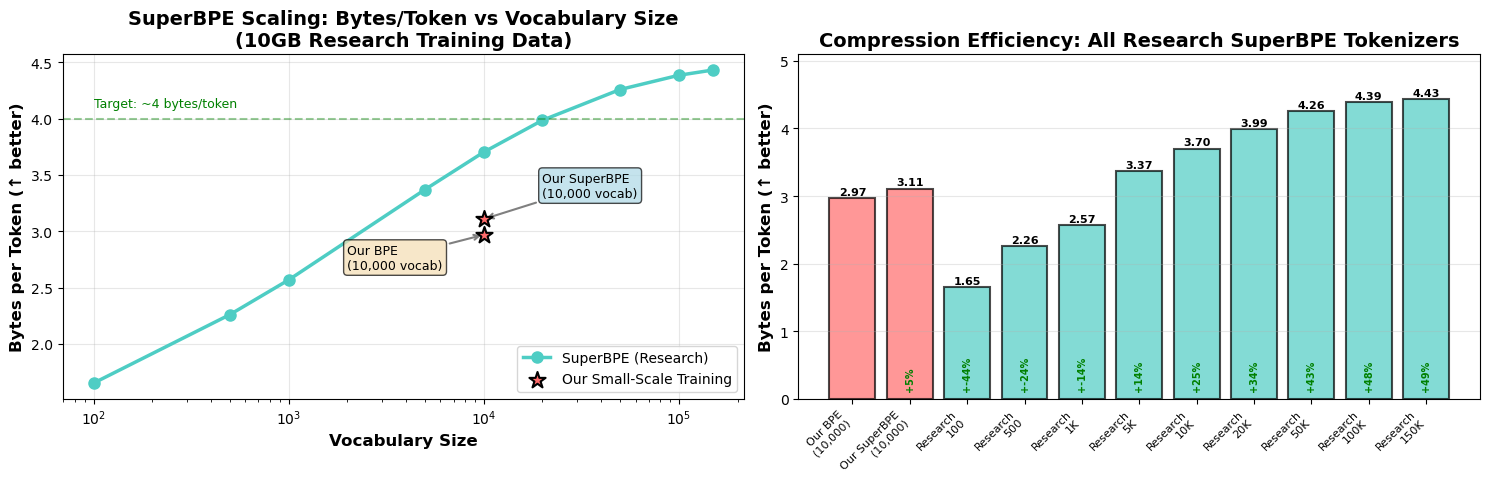

In [23]:
# Visualize the scaling behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Scaling curve
vocab_sizes = [d['vocab_size'] for d in scaling_data]
bytes_per_token_values = [d['bytes_per_token'] for d in scaling_data]

ax1.plot(vocab_sizes, bytes_per_token_values, marker='o', linewidth=2.5, 
         markersize=8, color='#4ECDC4', label='SuperBPE (Research)')

# Get our actual tokenizer values from the comparison
our_bpe_vocab = bpe_tokenizer.get_vocab_size()
our_superbpe_vocab = superbpe_tokenizer.get_vocab_size()
our_bpe_bpt = float(tokenizer_comparison[0]['Bytes/Token'])
our_superbpe_bpt = float(tokenizer_comparison[1]['Bytes/Token'])

# Add our small-scale results for comparison
ax1.scatter([our_bpe_vocab, our_superbpe_vocab], [our_bpe_bpt, our_superbpe_bpt], 
            s=150, color='#FF6B6B', marker='*', zorder=5, 
            label='Our Small-Scale Training', edgecolors='black', linewidths=1.5)

# Annotate our points
ax1.annotate(f'Our BPE\n({our_bpe_vocab:,} vocab)', 
            xy=(our_bpe_vocab, our_bpe_bpt), xytext=(2000, our_bpe_bpt - 0.3),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            fontsize=9, ha='left', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax1.annotate(f'Our SuperBPE\n({our_superbpe_vocab:,} vocab)', 
            xy=(our_superbpe_vocab, our_superbpe_bpt), xytext=(20000, our_superbpe_bpt + 0.2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            fontsize=9, ha='left', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax1.set_xlabel('Vocabulary Size', fontsize=12, fontweight='bold')
ax1.set_ylabel('Bytes per Token (↑ better)', fontsize=12, fontweight='bold')
ax1.set_title('SuperBPE Scaling: Bytes/Token vs Vocabulary Size\n(10GB Research Training Data)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.legend(fontsize=10)
ax1.axhline(y=4.0, color='green', linestyle='--', alpha=0.4, label='4.0 bytes/token')
ax1.text(100, 4.1, 'Target: ~4 bytes/token', fontsize=9, color='green')

# Plot 2: Bar comparison - include ALL research tokenizers
comparison_data = [
    (f'Our BPE\n({our_bpe_vocab:,})', our_bpe_bpt, '#FF6B6B'),
    (f'Our SuperBPE\n({our_superbpe_vocab:,})', our_superbpe_bpt, '#FF6B6B'),
]

# Add all research tokenizers from scaling_data
for d in scaling_data:
    vocab_k = d['vocab_size'] / 1000 if d['vocab_size'] >= 1000 else d['vocab_size']
    unit = 'K' if d['vocab_size'] >= 1000 else ''
    label = f'Research\n{vocab_k:.0f}{unit}' if vocab_k == int(vocab_k) else f'Research\n{vocab_k:.1f}{unit}'
    comparison_data.append((label, d['bytes_per_token'], '#4ECDC4'))

labels = [d[0] for d in comparison_data]
values = [d[1] for d in comparison_data]
colors = [d[2] for d in comparison_data]

bars = ax2.bar(range(len(labels)), values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    ax2.text(i, val + 0.05, f'{val:.2f}', ha='center', fontweight='bold', fontsize=8)

ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax2.set_ylabel('Bytes per Token (↑ better)', fontsize=12, fontweight='bold')
ax2.set_title('Compression Efficiency: All Research SuperBPE Tokenizers', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(values) * 1.15)

# Add improvement annotations for our tokenizers and selected research ones
improvement_indices = [1] + list(range(2, len(comparison_data)))
for i in improvement_indices:
    improvement = 100 * (values[i] - values[0]) / values[0]
    ax2.text(i, 0.15, f'+{improvement:.0f}%', ha='center', fontsize=7, 
             fontweight='bold', color='green', rotation=90)

plt.tight_layout()
plt.show()